# Clustering Analysis - (K-Means, Hierarchical & DBSCAN Algorithms)

## Objective

The objective of this assignment is to study and compare multiple clustering algorithms,
namely **K-Means, Hierarchical Clustering, and DBSCAN**, and to gain hands-on experience
in applying these techniques to a real-world airline customer dataset for meaningful
customer segmentation.

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
file_path = "EastWestAirlines.xlsx"
xls = pd.ExcelFile(file_path)
xls.sheet_names

['Description', 'data']

In [3]:
df_info = pd.read_excel(file_path, sheet_name="Description")
df = pd.read_excel(file_path, sheet_name="data")

## Data Preprocessing

### Dataset Structure

In [4]:
df_info

,East-West Airlines is trying to learn more about its customers. Key issues are their,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,"flying patterns, earning and use of frequent f...",NaN,NaN,NaN,NaN
1,card. The task is to identify customer segmen...,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,Source: Based upon real business data; company...,NaN,NaN,NaN,NaN
5,(c) 2016 Galit Shmueli and Peter Bruce,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN
8,Field Name,Data Type,Max Data Length,Raw Data or Telcom Created Field?,Description
9,ID#,NUMBER,NaN,Telcom,Unique ID


In [5]:
df.shape

(3999, 12)

In [6]:
# Basic Info
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


### Statistical Summary

In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


### Check Missing Values

In [8]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

The dataset was examined for missing values across all features.
No missing values were observed; therefore, no imputation was required.

### Remove Identifier Column

In [9]:
 # Dropping ID column as it is not needed for clustering
df = df.drop(columns=['ID#']) 
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


### Outlier Detection

In [10]:
# Z-score based outlier detection
z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
outliers = (z_scores > 3).sum(axis=0)
outliers

array([75, 83,  0, 43, 18, 72, 47, 78, 91,  0,  0])

Z-score analysis was used to identify extreme values.
Although some features show extreme observations, these were retained because they
represent genuine high-value airline customers.
Removing them could result in loss of important behavioral information.

### Outlier Detection (Boxplot)

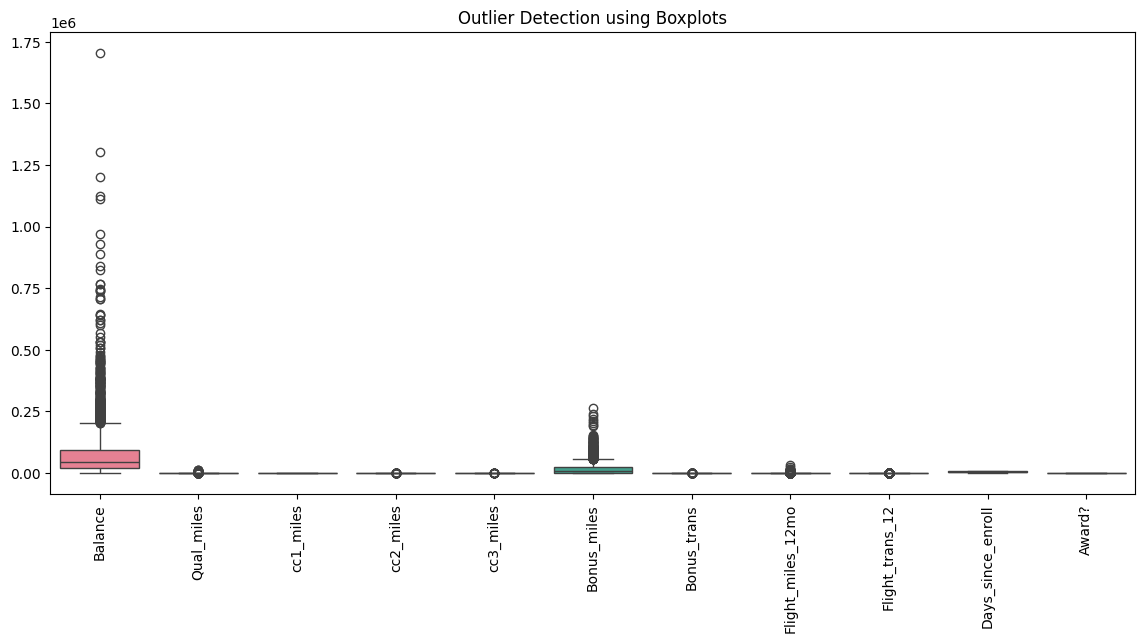

In [11]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Outlier Detection using Boxplots")
plt.show()

### Feature Scaling

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

## EXPLORATORY DATA ANALYSIS (EDA)

### Distribution Analysis (Histograms)

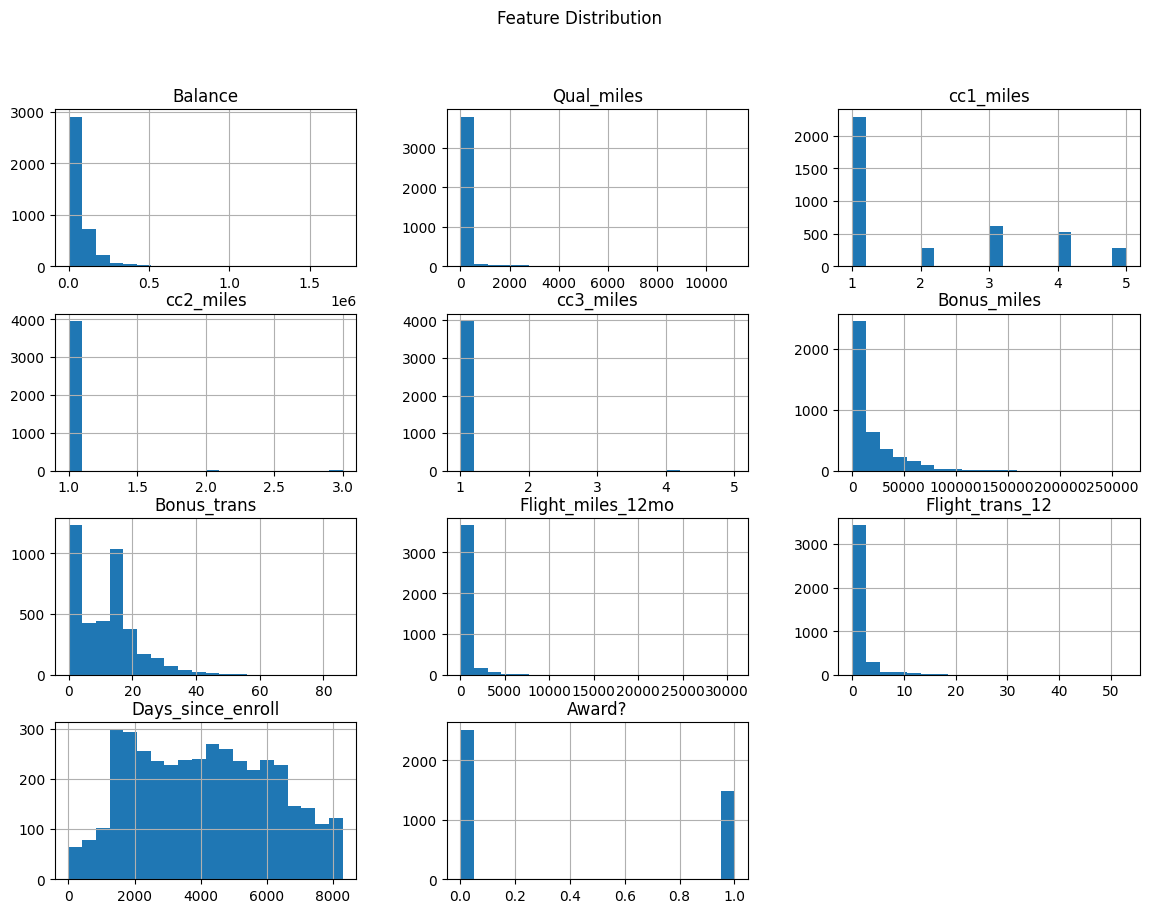

In [13]:
df.hist(figsize=(14,10), bins=20)
plt.suptitle("Feature Distribution")
plt.show()

### Correlation Heatmap

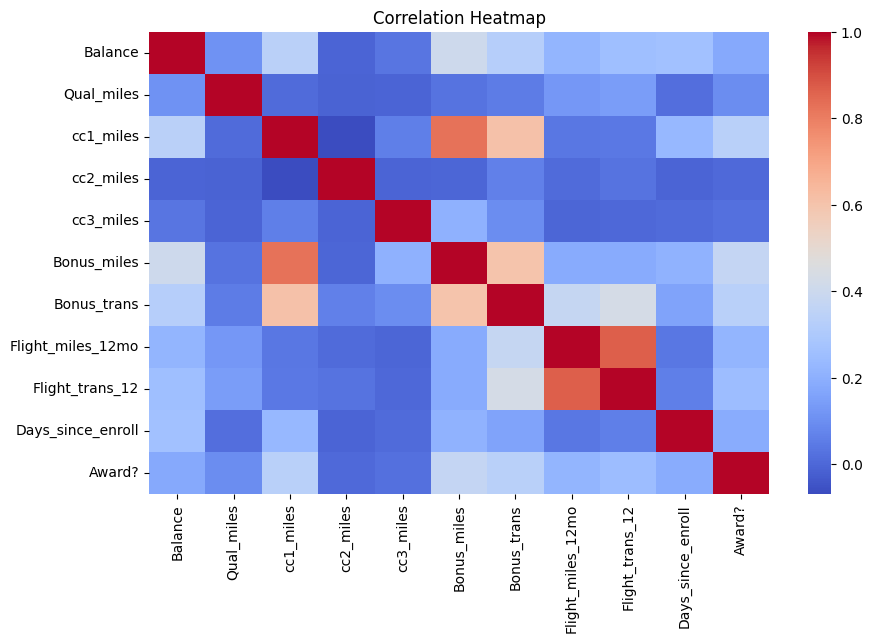

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(X_scaled_df.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Pairwise Relationship Visualization

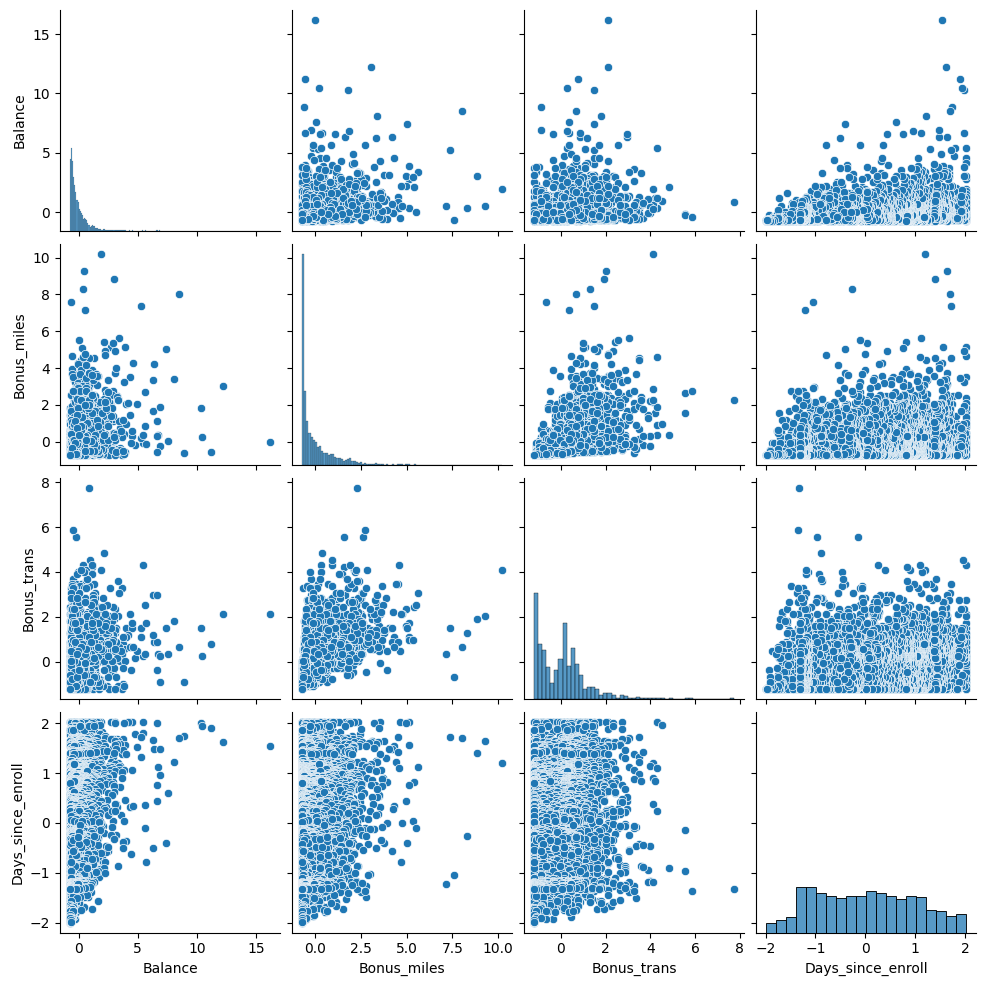

In [15]:
sns.pairplot(X_scaled_df[['Balance', 'Bonus_miles', 'Bonus_trans', 'Days_since_enroll']])
plt.show()

### Scatter Plot – Hidden Pattern Check

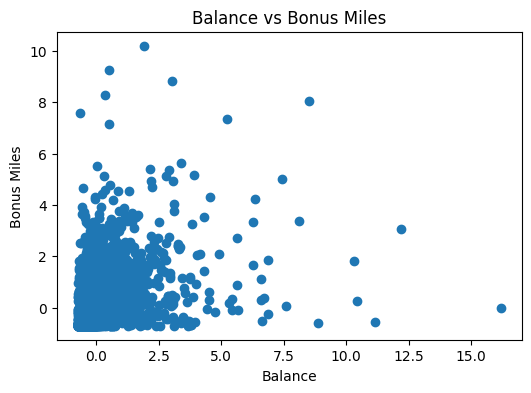

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled_df['Balance'], X_scaled_df['Bonus_miles'])
plt.xlabel("Balance")
plt.ylabel("Bonus Miles")
plt.title("Balance vs Bonus Miles")
plt.show()

### Density Plot

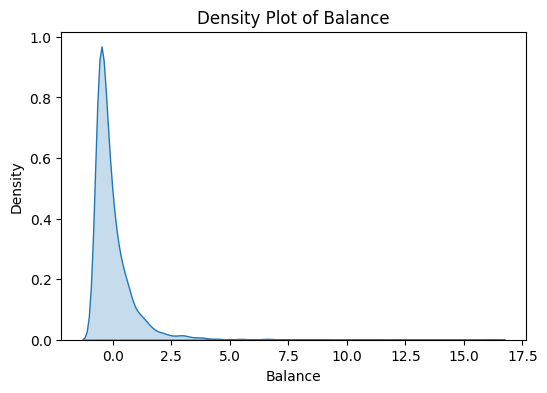

In [17]:
plt.figure(figsize=(6,4))
sns.kdeplot(X_scaled_df['Balance'], fill=True)
plt.title("Density Plot of Balance")
plt.show()

### EDA Summary for Clustering 

EDA indicates high variance across mileage, transaction, and balance-related features.
This variation suggests the presence of heterogeneous customer groups, making the dataset
suitable for clustering-based segmentation.


## Implementing Clustering Algorithms

## K-MEANS CLUSTERING

### K-Means – Elbow Method (Parameter Tuning)

In [18]:
inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

### Elbow Curve Visualization

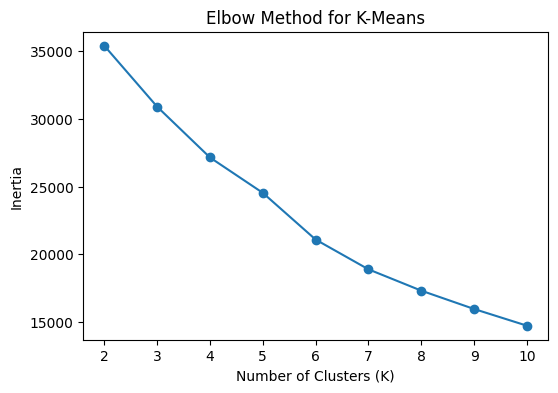

In [19]:
plt.figure(figsize=(6,4))
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

### Elbow Curve Interpretation

The elbow curve shows a noticeable flattening after the selected value of K.
This indicates diminishing returns in reducing inertia beyond this point,
making the chosen number of clusters optimal for K-Means.

### Apply K-Means (Optimal K = 4)

In [20]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

### Add K-Means Cluster Labels

In [ ]:
df['KMeans_Cluster'] = kmeans_labels

## HIERARCHICAL CLUSTERING 

### Dendrogram (Parameter Exploration)

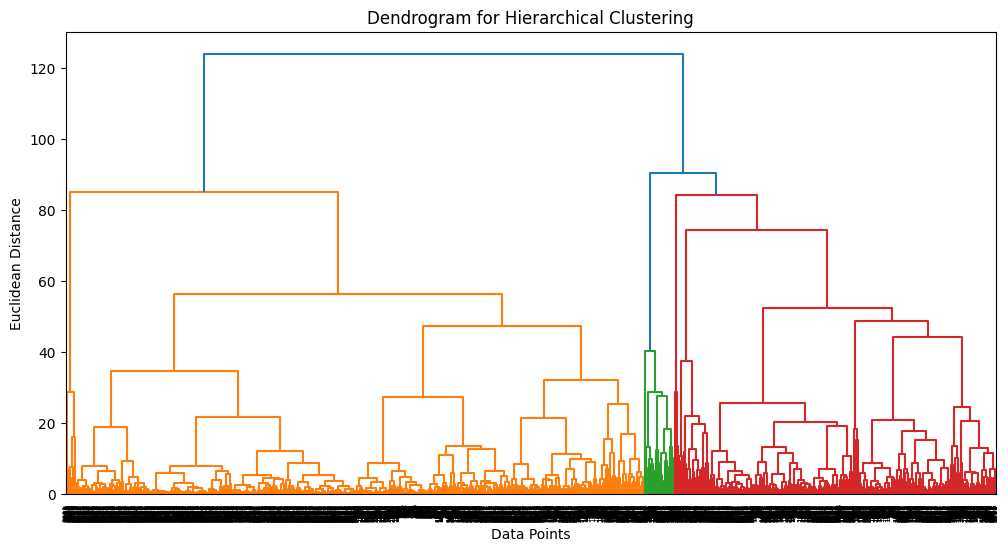

In [22]:
# Perform hierarchical clustering using Ward linkage
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Euclidean Distance")
plt.show()

### Agglomerative Clustering

In [23]:
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(X_scaled)

### Add Hierarchical Cluster Labels

In [24]:
df['Hierarchical_Cluster'] = hierarchical_labels

## DBSCAN CLUSTERING

In [25]:
# Nearest Neighbors for k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances
distances = np.sort(distances[:, 4])

### Plot k-distance graph

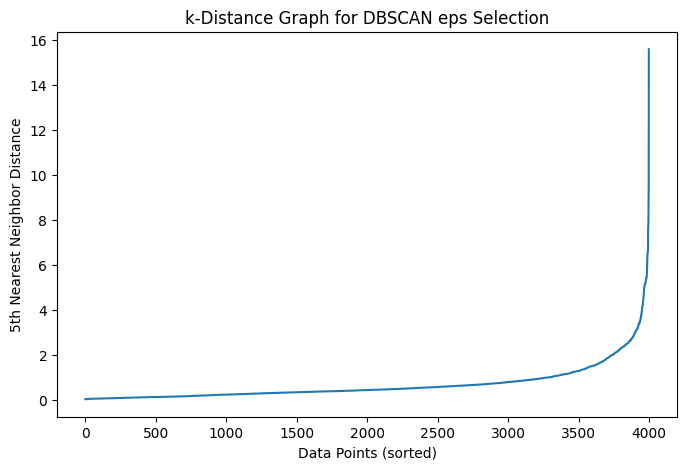

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel("Data Points (sorted)")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("k-Distance Graph for DBSCAN eps Selection")
plt.show()

From the k-distance graph, an elbow point is observed where the distance
starts increasing sharply. This point represents a suitable value for eps.

Based on this observation:
- **eps** is chosen to capture dense regions without merging distinct clusters
- **minPts = 5** is selected as a standard rule of thumb for multi-dimensional data

These parameters allow DBSCAN to effectively identify dense customer groups
and detect noise points (outliers) in the airline dataset.

### DBSCAN EPS TUNING

In [27]:
for eps in [0.8, 1.2, 1.7]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(X_scaled)
    print("eps =", eps, " | clusters =", len(set(labels)) - (1 if -1 in labels else 0))

eps = 0.8  | clusters = 8
eps = 1.2  | clusters = 5
eps = 1.7  | clusters = 6


### DBSCAN EPS Selection

At very low eps values (e.g., 0.1), DBSCAN produced a large number of small clusters,
indicating over-fragmentation of the data.

As eps increased, the number of clusters gradually decreased and stabilized at **5 clusters**
from eps = 1.2 onward. This stability indicates a natural grouping structure in the dataset.

Therefore, **eps = 1.2** was selected as the optimal value, as it provides a good balance
between meaningful cluster formation and cluster stability.

### DBSCAN – Parameter Experimentation

In [28]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
# Count noise points
np.unique(dbscan_labels, return_counts=True)

(array([-1,  0,  1,  2,  3,  4], dtype=int64),
 array([ 443, 2379, 1150,   14,    8,    5], dtype=int64))

### Add DBSCAN Cluster Labels

In [29]:
df['DBSCAN_Cluster'] = dbscan_labels

### DBSCAN Cluster Counts

In [30]:
df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    2379
 1    1150
-1     443
 2      14
 3       8
 4       5
Name: count, dtype: int64

## Visualization of Clustering Results

### PCA for Cluster Visualization

Principal Component Analysis (PCA) was applied to reduce high-dimensional data into
two components for visualization purposes.
PCA preserves maximum variance, enabling effective visual comparison of clustering results.

In [31]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

### K-Means Cluster Visualization

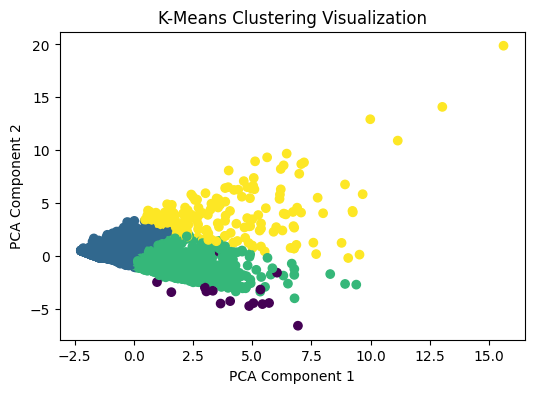

In [32]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clustering Visualization")
plt.show()

### Hierarchical Cluster Visualization

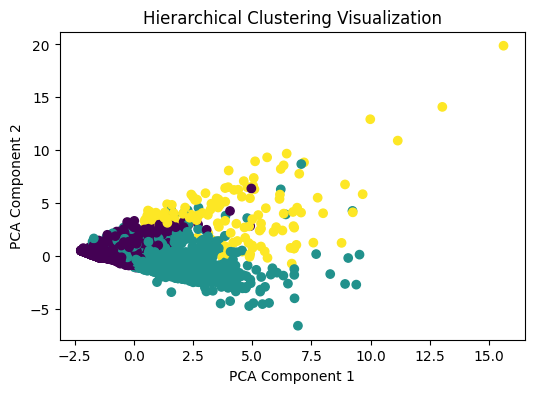

In [33]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=hierarchical_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Hierarchical Clustering Visualization")
plt.show()

### DBSCAN Cluster Visualization

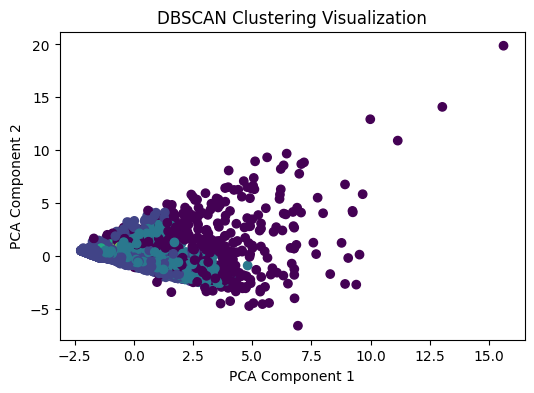

In [34]:
plt.figure(figsize=(6,4))
plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clustering Visualization")
plt.show()

## Evaluation and Performance Metrics

### K-Means Silhouette Score

In [35]:
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_silhouette

0.30918774313627845

### Hierarchical Silhouette Score

In [36]:
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)
hierarchical_silhouette

0.2940432062008608

### DBSCAN Silhouette Score (Ignoring Noise)

In [37]:
mask = dbscan_labels != -1
dbscan_silhouette = silhouette_score(X_scaled[mask], dbscan_labels[mask])
dbscan_silhouette

0.2709994608096493

### Comparative Evaluation of Clustering Algorithms

In [38]:
print("K-Means Silhouette Score:", kmeans_silhouette)
print("DBSCAN Silhouette Score:", dbscan_silhouette)
print("Hierarchical Clustering Silhouette Score:", hierarchical_silhouette)

K-Means Silhouette Score: 0.30918774313627845
DBSCAN Silhouette Score: 0.2709994608096493
Hierarchical Clustering Silhouette Score: 0.2940432062008608


### Algorithm Comparison

- K-Means effectively segmented customers into well-separated groups.
- Hierarchical clustering provided insights into nested customer relationships.
- DBSCAN identified dense regions and irregular customer behavior.

Each algorithm contributed uniquely toward achieving the objective of understanding
different clustering approaches on real-world data.


## Cluster Analysis and Interpretation

* The clustering algorithms segmented airline customers based on their flight
activity, mileage, and loyalty-related attributes. Each cluster represents
a distinct type of customer behavior.

### K-Means Cluster Characteristics

In [39]:
df.groupby('KMeans_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333,1.000000,-1.000000
1,43793.917814,97.436886,1.221785,1.019269,1.000393,4700.690916,6.918993,198.621707,0.618168,3691.559969,0.201337,0.062525,0.180102
2,116817.336214,154.756481,3.701493,1.002357,1.001571,39216.199529,18.759623,334.355852,0.997643,4893.491752,0.648075,0.942655,0.380990
3,191573.726190,775.863095,2.172619,1.035714,1.000000,31412.160714,26.779762,5365.672619,15.636905,4665.827381,0.809524,1.583333,-0.886905


- **Cluster 0:** High mileage balance with low flight activity, indicating customers who earn miles mainly through bonus programs rather than frequent flying.  
- **Cluster 1:** Low balance and minimal flight activity, representing occasional or low-value customers with limited loyalty engagement.  
- **Cluster 2:** High mileage balance with moderate flight activity and strong award usage, indicating loyal and consistent airline customers.  
- **Cluster 3:** Extremely high flight miles and transactions with strong loyalty engagement, representing premium and very frequent flyers.

### Hierarchical Cluster Characteristics

In [40]:
df.groupby('Hierarchical_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,DBSCAN_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,
0,46718.863399,9.274407,1.242266,1.023303,1.000000,5037.792688,7.091201,221.167135,0.700281,3772.785858,0.188027,1.048614,0.171555
1,116314.450725,363.839130,3.498551,1.000000,1.035507,37150.356522,18.066667,377.000000,1.150000,4696.888406,0.663043,1.890580,0.340580
2,134880.892308,393.323077,2.430769,1.000000,1.000000,36582.169231,29.338462,5915.523077,16.638462,4599.607692,0.753846,2.876923,-0.907692


- **Cluster 0:** Low mileage balance and very low flight activity, representing infrequent and low-engagement customers.  
- **Cluster 1:** High mileage balance with moderate flight activity and good award usage, indicating loyal and regular customers.  
- **Cluster 2:** Very high flight miles and transactions with strong loyalty engagement, representing premium and highly frequent flyers.

### DBSCAN Cluster Characteristics

In [41]:
df.groupby('DBSCAN_Cluster').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,Hierarchical_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,
-1,195593.634312,1113.530474,2.762980,1.063205,1.110609,42315.851016,23.503386,2488.069977,7.255079,4792.004515,0.735892,2.115124,1.144470
0,55098.400168,21.784784,1.672131,1.000000,1.000000,9345.203867,8.590164,158.897436,0.472467,3799.493485,0.000000,1.176124,0.171080
1,65679.625217,18.853913,2.604348,1.000000,1.000000,23626.286957,13.202609,310.722609,0.996522,4533.683478,1.000000,1.587826,0.626957
2,34032.142857,0.000000,1.000000,2.000000,1.000000,8312.500000,12.285714,57.142857,0.357143,3315.928571,0.000000,1.000000,0.000000
3,36524.250000,0.000000,1.000000,3.000000,1.000000,15518.500000,14.500000,50.000000,0.250000,3179.625000,0.000000,1.000000,0.000000
4,60884.400000,1902.400000,3.400000,1.000000,1.000000,34665.000000,15.400000,200.000000,0.400000,4534.000000,1.000000,2.000000,1.000000


- **Cluster -1 (Noise):** Extremely high mileage balance and flight activity, representing outliers or exceptional premium customers with irregular behavior.  
- **Cluster 0:** Low mileage balance and minimal flight activity, indicating infrequent and low-engagement customers.  
- **Cluster 1:** Moderate mileage balance with some flight activity and full award usage, representing regular but not premium customers.  
- **Cluster 2:** Very low balance and almost no qualifying miles, indicating inactive or newly enrolled customers.  
- **Cluster 3:** Low balance with minimal flight transactions, representing rarely active customers with limited loyalty engagement.  
- **Cluster 4:** High qualifying miles and bonus activity with moderate flights, indicating high-value and loyalty-driven customers.

### Final Conclusion

Based on silhouette score evaluation, K-Means clustering performs best for this dataset, followed closely by Hierarchical clustering.
DBSCAN shows comparatively lower performance, indicating that the dataset does not strongly exhibit density-based cluster structures.
Overall, K-Means is the most suitable clustering technique for this dataset.